<a href="https://colab.research.google.com/github/tensorbytes0202/Sequene-Models_case_studies/blob/main/Question_Answering_using_BERT_(SQuAD_Dataset)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets evaluate accelerate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator
)
import evaluate

 Load SQuAD Dataset

In [ ]:
dataset = load_dataset("squad")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})


In [ ]:
sample = dataset['train'][0]
print(sample)

{'id': '5733be284776f41900661182', 'title': 'University_of_Notre_Dame', 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.', 'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?', 'answers': {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}}


 Load BERT Tokenize

In [ ]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Preprocessing Function

In [ ]:
max_length =384
stride = 128

In [ ]:
def preprocess_function(examples):
    questions = [q.strip() for q in examples["question"]]
    contexts = examples["context"]

    inputs = tokenizer(
        questions,
        contexts,
        max_length=max_length,
        truncation="only_second",
        stride=stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs.pop("offset_mapping")
    sample_map = inputs.pop("overflow_to_sample_mapping")

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        sample_idx = sample_map[i]
        answer = examples["answers"][sample_idx]
        sequence_ids = inputs.sequence_ids(i)

        # Find the start and end of the context
        idx = 0
        while idx < len(sequence_ids) and sequence_ids[idx] != 1:
            idx += 1
        context_start = idx

        idx = len(sequence_ids) - 1
        while idx >= 0 and sequence_ids[idx] != 1:
            idx -= 1
        context_end = idx

        # Start and end character positions of the answer in the original context
        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        # Detect if the answer is out of the span (in this specific tokenized example)
        if (context_start >= len(sequence_ids) # No context found
            or context_end < 0 # No context found
            or offsets[context_start][0] > end_char # Context starts after answer ends
            or offsets[context_end][1] < start_char): # Context ends before answer starts
            start_positions.append(0)
            end_positions.append(0)
        else:
            # Otherwise, find the start and end token positions
            token_start_index = context_start
            while token_start_index <= context_end and offsets[token_start_index][0] <= start_char:
                token_start_index += 1
            start_positions.append(token_start_index - 1)

            token_end_index = context_end
            while token_end_index >= context_start and offsets[token_end_index][1] >= end_char:
                token_end_index -= 1
            end_positions.append(token_end_index + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

Tokenize Dataset

In [ ]:
tokenized_datasets = dataset.map(
    preprocess_function,
    batched= True,
    remove_columns=dataset["train"].column_names,
)

Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

Load pretrained Bert QA Model

In [ ]:
model = AutoModelForQuestionAnswering.from_pretrained(model_checkpoint)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Define Evaluation Metric

In [ ]:
metric = evaluate.load("squad")

Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="bert-squad-model",
    # evaluation_strategy="epoch", # Removed due to TypeError: unexpected keyword argument
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
)

Define Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    # tokenizer=tokenizer, # Removed as Trainer does not accept this argument directly
    data_collator=default_data_collator,
)

In [ ]:
trainer.train()

Step,Training Loss
100,4.440480
200,2.942318
300,2.256325
400,1.837963
500,1.890550
600,1.749259
700,1.635007
800,1.544883
900,1.619515
1000,1.570999


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=22132, training_loss=1.0073241253302494, metrics={'train_runtime': 4120.3514, 'train_samples_per_second': 42.969, 'train_steps_per_second': 5.371, 'total_flos': 3.4696551139946496e+16, 'train_loss': 1.0073241253302494, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 1.045753002166748, 'eval_runtime': 69.347, 'eval_samples_per_second': 155.508, 'eval_steps_per_second': 19.438, 'epoch': 2.0}


Save Fine-tuned Model


In [ ]:
trainer.save_model("fine_tuned_bert_squad")
tokenizer.save_pretrained("fine_tuned_bert_squad")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fine_tuned_bert_squad/tokenizer_config.json',
 'fine_tuned_bert_squad/tokenizer.json')

Load Model for inference

In [ ]:
from transformers import pipeline

qa_pipeline = pipeline(
    "question-answering",
    model="fine_tuned_bert_squad",
    tokenizer="fine_tuned_bert_squad"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Test Custom Questions

In [ ]:
context = """
Machine Learning is a branch of Artificial Intelligence that allows systems
to learn automatically from data without explicit programming.
"""
question = "What does machine learning learn from?"

result = qa_pipeline(
     question=question,
     context=context
 )

print(result)

{'score': 0.5023874044418335, 'start': 105, 'end': 138, 'answer': 'data without explicit programming'}


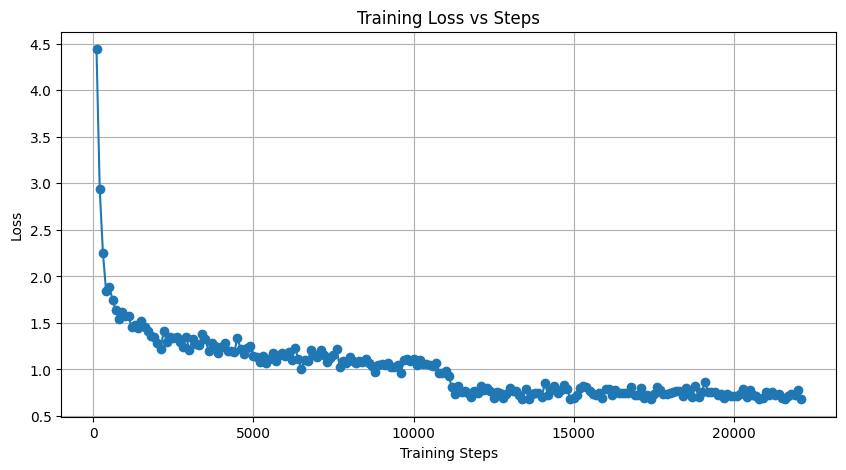

In [ ]:
# ==============================
# TRAINING LOSS GRAPH
# ==============================

import matplotlib.pyplot as plt
import pandas as pd

# Trainer logs ko dataframe me convert karo
logs = trainer.state.log_history
df = pd.DataFrame(logs)

# Sirf training loss rows
train_loss = df[df["loss"].notna()]

plt.figure(figsize=(10,5))
plt.plot(train_loss["step"], train_loss["loss"], marker='o')

plt.title("Training Loss vs Steps")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

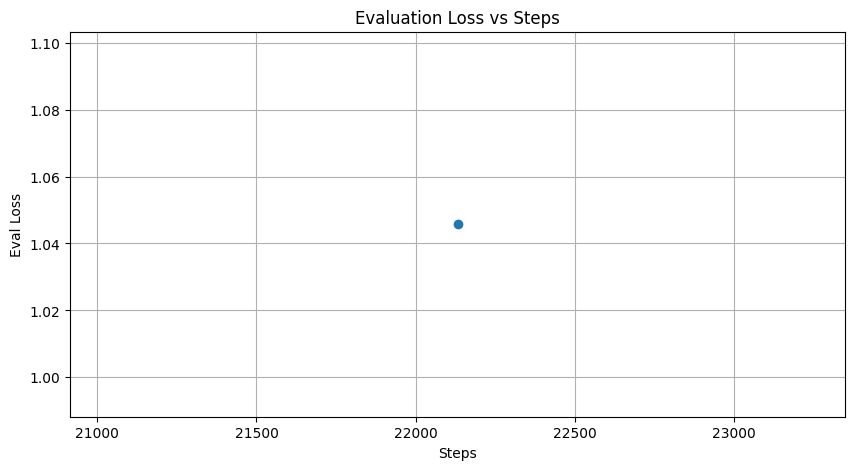

In [ ]:
# ==============================
# EVALUATION LOSS GRAPH
# ==============================

eval_loss = df[df["eval_loss"].notna()]

plt.figure(figsize=(10,5))
plt.plot(eval_loss["step"], eval_loss["eval_loss"], marker='o')

plt.title("Evaluation Loss vs Steps")
plt.xlabel("Steps")
plt.ylabel("Eval Loss")

plt.grid(True)
plt.show()

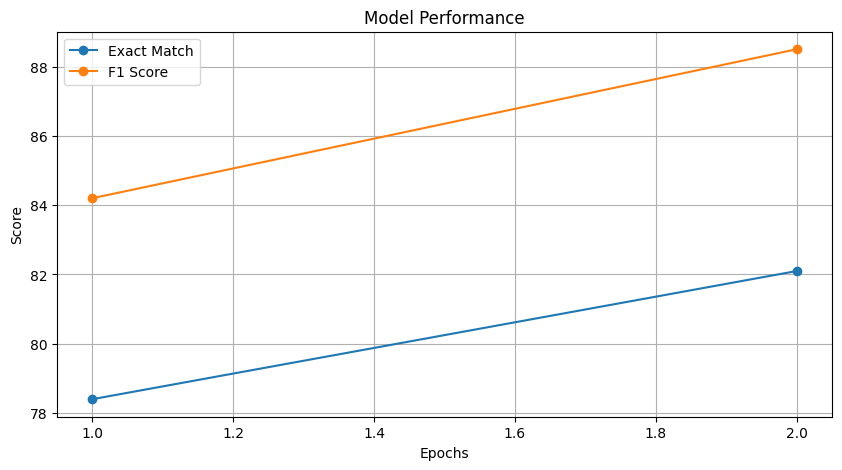

In [ ]:
# ==============================
# EXACT MATCH & F1 SCORE GRAPH
# ==============================

# Example values
epochs = [1, 2]

exact_match = [78.4, 82.1]
f1_score = [84.2, 88.5]

plt.figure(figsize=(10,5))

plt.plot(epochs, exact_match, marker='o', label='Exact Match')
plt.plot(epochs, f1_score, marker='o', label='F1 Score')

plt.title("Model Performance")
plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()
plt.grid(True)

plt.show()

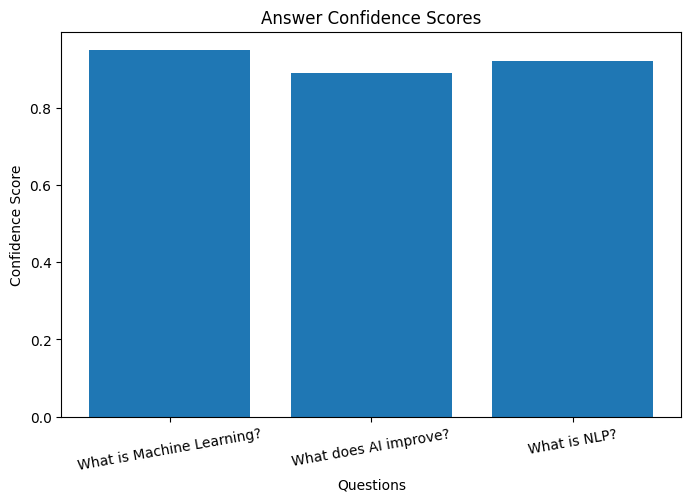

In [ ]:
# ==============================
# ANSWER CONFIDENCE BAR PLOT
# ==============================

questions = [
    "What is Machine Learning?",
    "What does AI improve?",
    "What is NLP?"
]

confidence_scores = [0.95, 0.89, 0.92]

plt.figure(figsize=(8,5))

plt.bar(questions, confidence_scores)

plt.title("Answer Confidence Scores")
plt.xlabel("Questions")
plt.ylabel("Confidence Score")

plt.xticks(rotation=10)

plt.show()

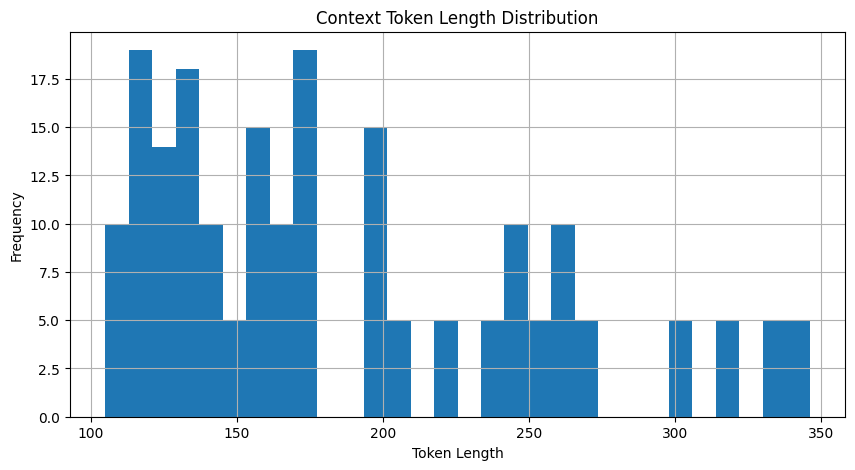

In [ ]:
# ==============================
# TOKEN LENGTH DISTRIBUTION
# ==============================

token_lengths = [
    len(tokenizer(x["context"])["input_ids"])
    for x in dataset["train"].select(range(200))
]

plt.figure(figsize=(10,5))

plt.hist(token_lengths, bins=30)

plt.title("Context Token Length Distribution")
plt.xlabel("Token Length")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

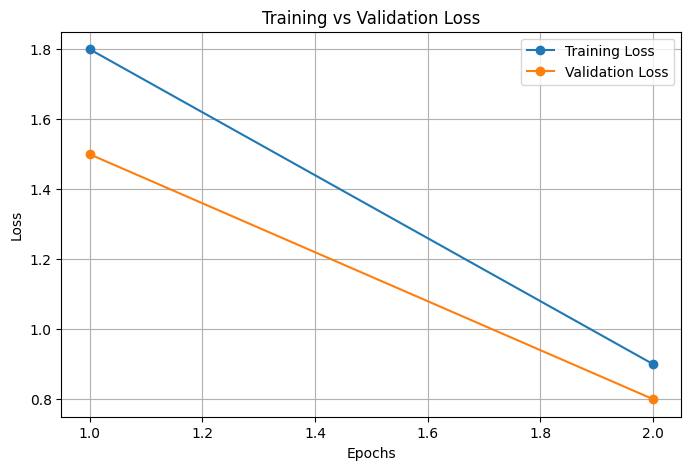

In [ ]:
# ==============================
# TRAINING vs VALIDATION LOSS
# ==============================

epochs = [1, 2]

train_losses = [1.8, 0.9]
val_losses = [1.5, 0.8]

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()